# Аудит данных: мусор на аэроснимках

Участник А. Цель — проверить реальные данные до обучения. UAVVaste содержит один класс `rubbish`; он не доказывает качество на Каспийском море и не содержит подтверждённых классов материалов. Источник: https://github.com/PUTvision/UAVVaste .

In [1]:
from pathlib import Path
import os, sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'data').is_dir())
os.chdir(ROOT)
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
print(ROOT)


C:\Users\azatm2\projects\outpeer-cv


## Разметка COCO
Одна запись `images` описывает кадр, `annotations` — объекты. Bounding box COCO имеет вид `[x, y, width, height]` в пикселях. Отсутствие записи об объекте в неизвестной фотографии не является доказательством чистого фона.

In [2]:
import pandas as pd
annotations = ROOT / 'data/raw/uavvaste/annotations.json'
data = json.loads(annotations.read_text(encoding='utf-8'))
images_df = pd.DataFrame(data['images'])
objects_df = pd.DataFrame(data['annotations'])
classes_df = pd.DataFrame(data['categories'])
print(f'Images: {len(images_df)}, objects: {len(objects_df)}')
classes_df


Images: 772, objects: 3718


,supercategory,id,name
0,,0,rubbish


In [3]:
counts = objects_df.groupby('category_id').agg(objects=('id', 'size'), images=('image_id', 'nunique'))
classes_df.merge(counts, left_on='id', right_index=True, how='left').fillna(0)


,supercategory,id,name,objects,images
0,,0,rubbish,3718,772


## Проверка файлов, размеров объектов и визуализация
Функция сохраняет проверяемые CSV и графики. Диагностический порог 8 пикселей не равен официальному определению small objects в COCO.

In [4]:
from src.data.audit import audit
summary = audit(annotations, ROOT / 'data/raw/uavvaste/images', ROOT / 'reports/a/audit')
summary


{'images': 772,
 'annotations': 3718,
 'readable_images': 772,
 'classes': [{'class_id': 0,
   'name': 'rubbish',
   'objects': 3718,
   'images': 772}],
 'images_without_annotations': 0,
 'image_statuses': {'ok': 729,
  'exif_orientation_requires_review': 29,
  'multiple_frames_requires_review': 14},
 'annotation_issues': [],
 'objects_min_side_below_8px_at_640': 1275,
 'small_object_definition': 'Shorter box side <8px after aspect-preserving resize to 640px longest side; diagnostic, not COCO small-object AP.',
 'filename_groups': {'batch_d07': 92,
  'unverified_gopro': 38,
  'batch_s05': 44,
  'unverified_camera': 4,
  'unverified_photo': 6,
  'batch_s03': 41,
  'batch_s02': 157,
  'batch_02': 41,
  'batch_05': 48,
  'batch_s04': 62,
  'batch_01': 36,
  'batch_s01': 34,
  'batch_d06': 36,
  'unverified_dji': 2,
  'batch_03': 21,
  'batch_04': 54,
  'batch_d08': 56},
 'limitations': ['Filename groups are not verified flights or geographic locations.',
  'UAVVaste is a one-class litter

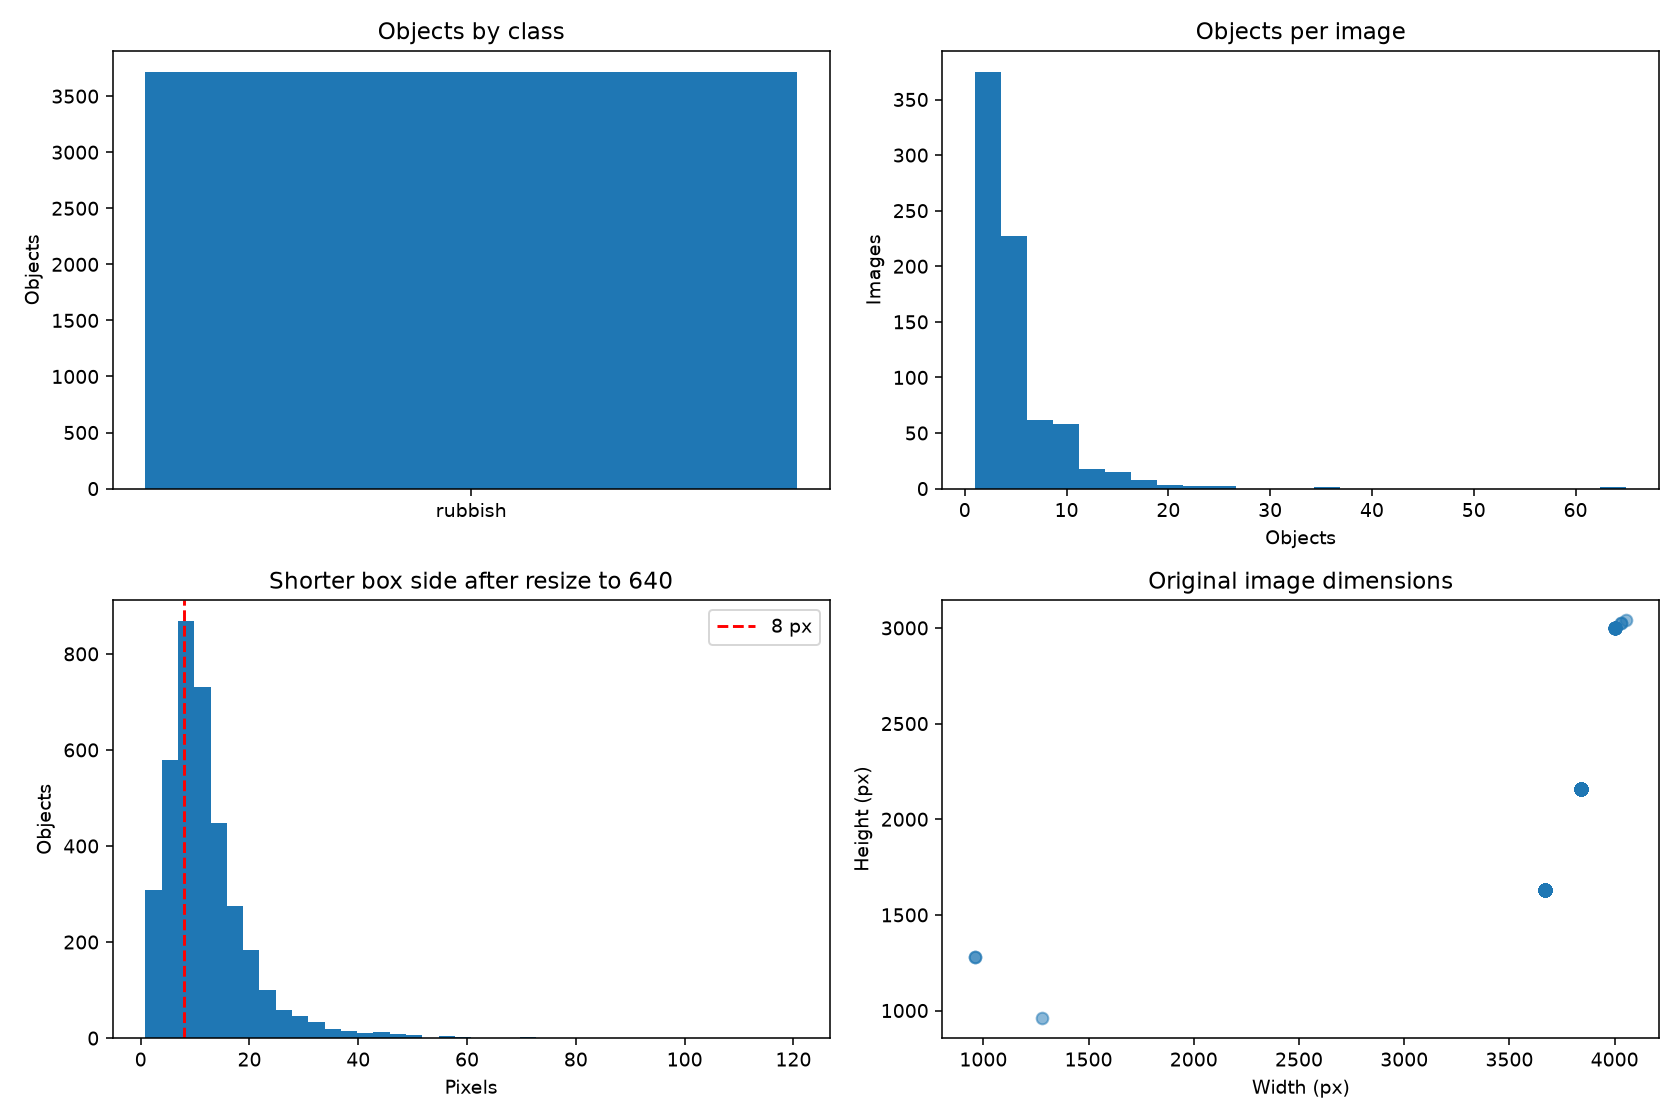

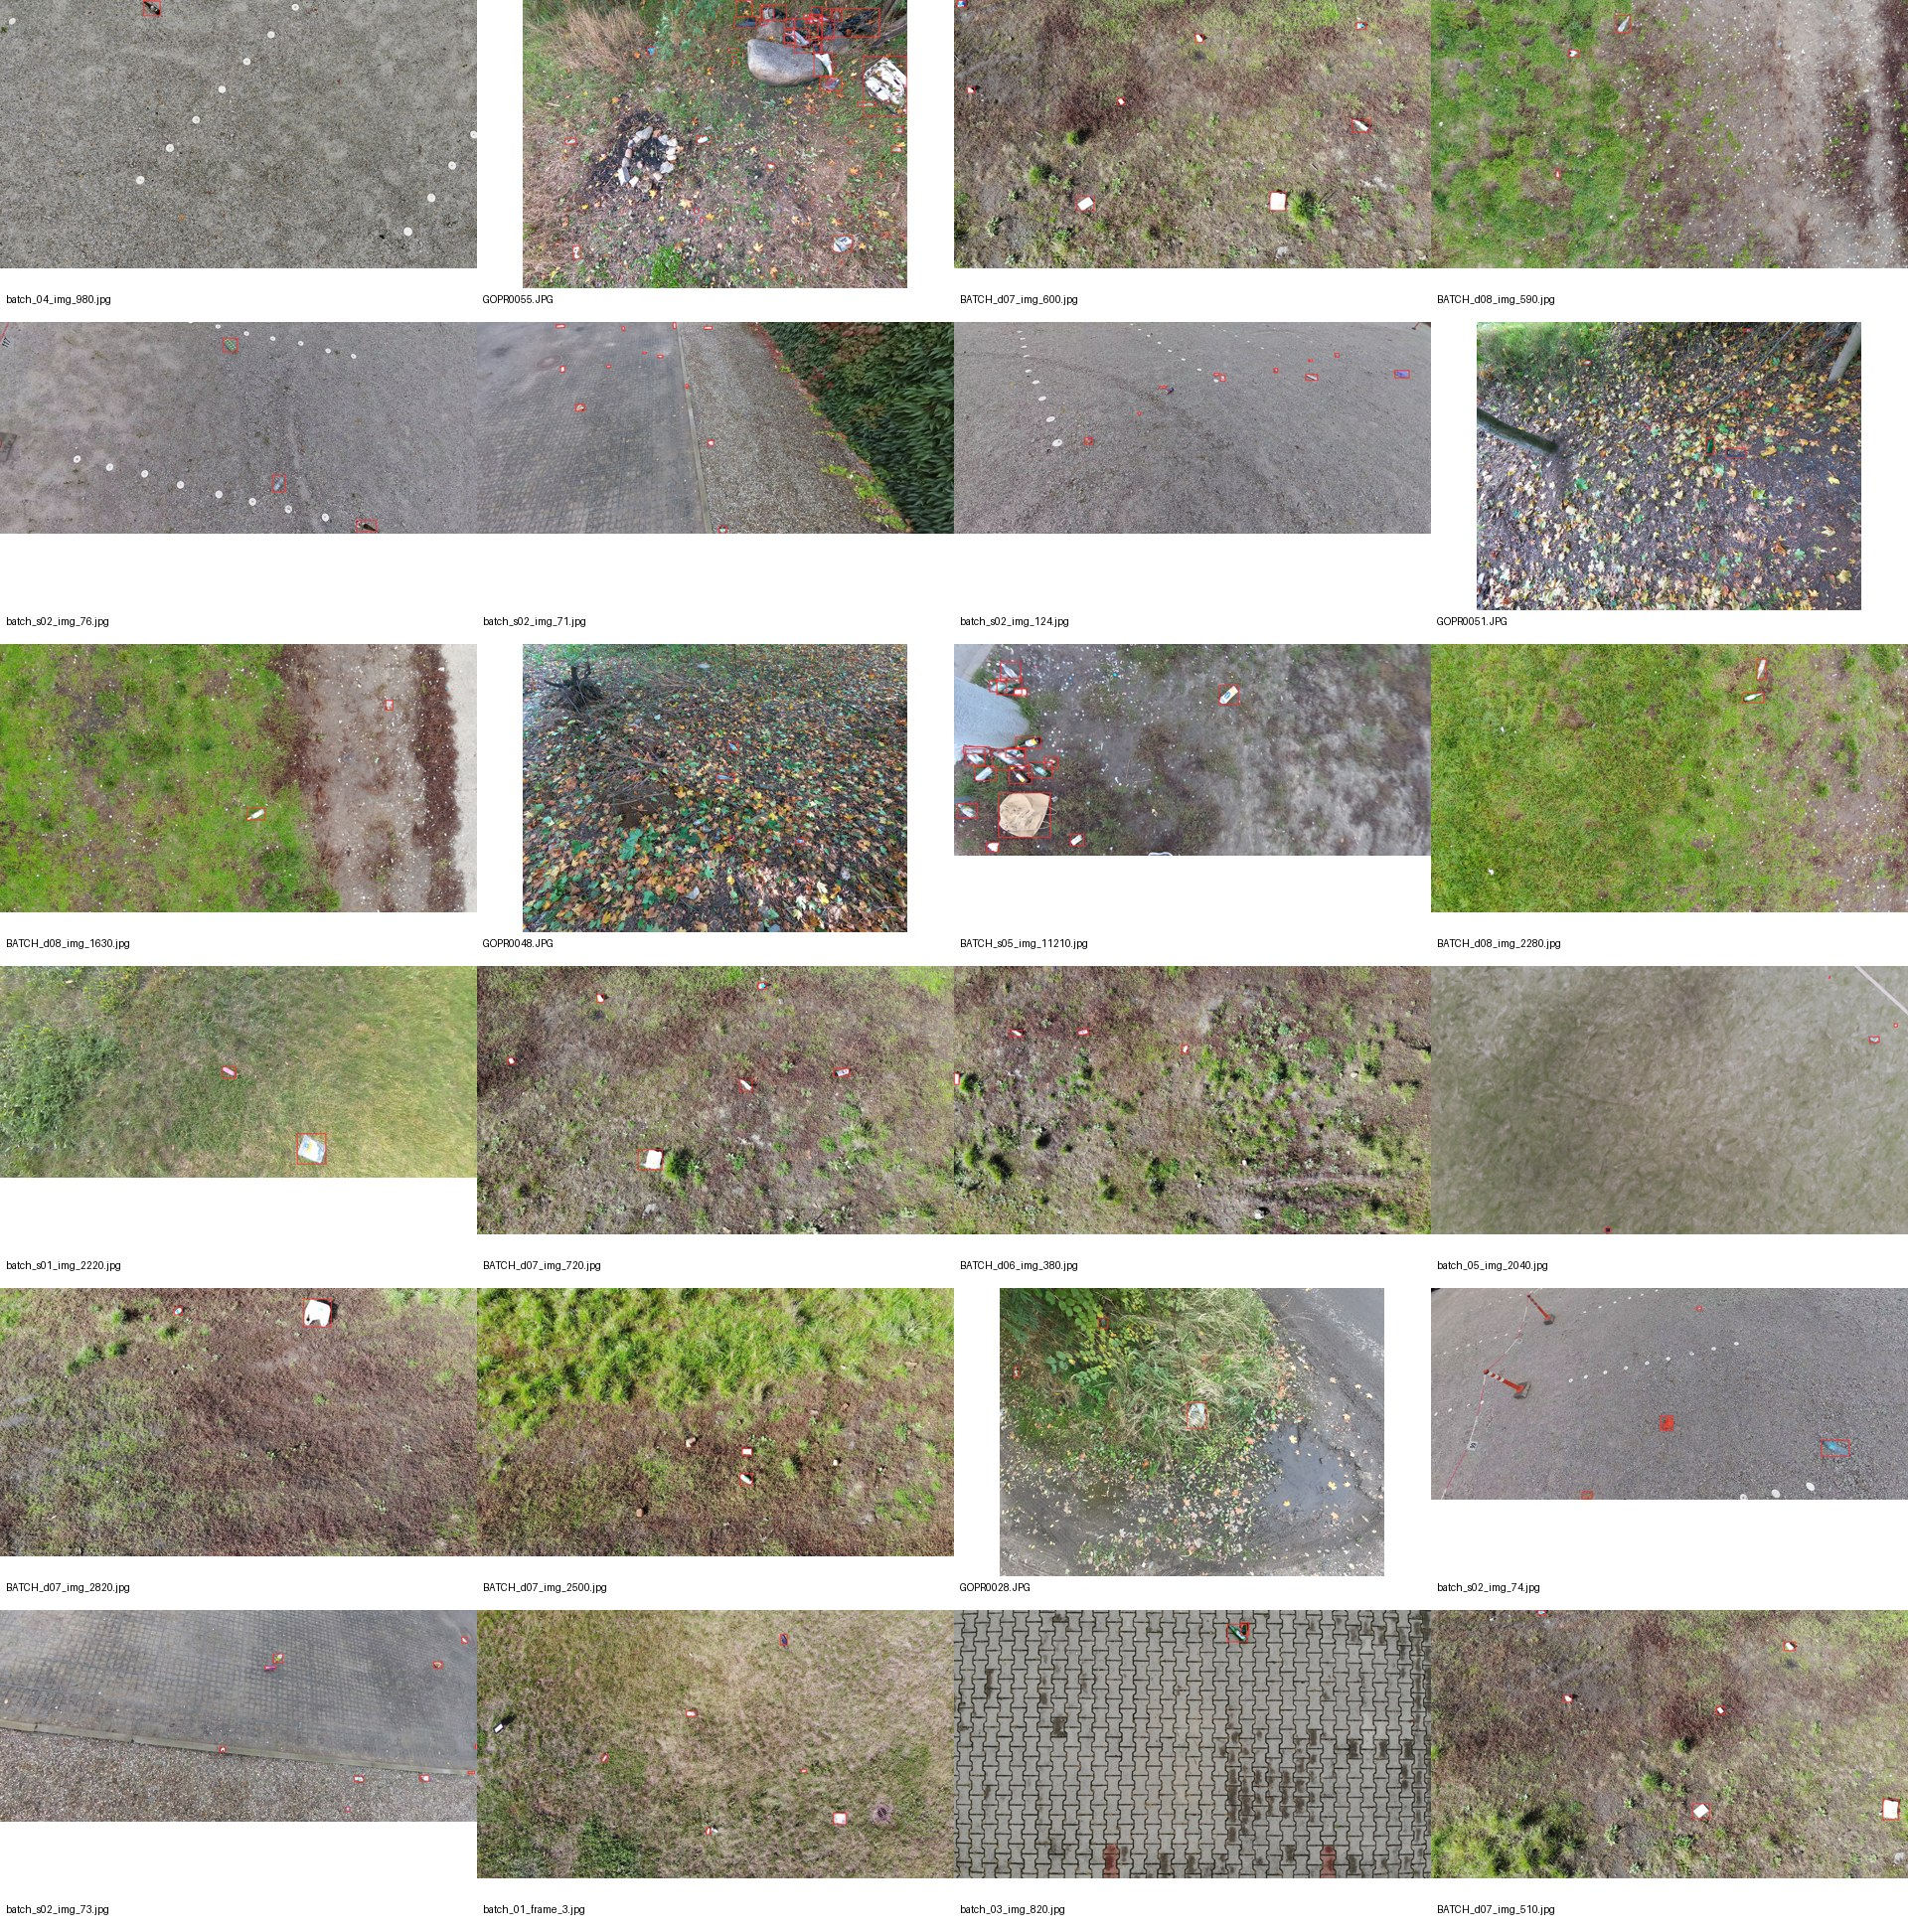

In [5]:
from IPython.display import display, Image as DisplayImage
display(DisplayImage(filename=str(ROOT / 'reports/a/audit/distributions.png')))
display(DisplayImage(filename=str(ROOT / 'reports/a/audit/annotated_examples.jpg'), width=1100))


## Разбиение и утечки
Соседние кадры одной серии должны оставаться вместе. `groups_suggested.csv` основан на именах файлов: это предположение о сериях, а не известные полёты. Контактные листы находятся в `reports/a/audit/contact_sheets`. До выводов о переносе на новые места необходимо подтвердить группы и проверить отдельные прибрежные снимки.

In [6]:
groups = pd.read_csv(ROOT / 'data/raw/uavvaste/groups_suggested.csv')
groups.groupby('group_id').size().sort_values(ascending=False).rename('images')


group_id
batch_s02            157
batch_d07             92
batch_s04             62
batch_d08             56
batch_04              54
batch_05              48
batch_s05             44
batch_s03             41
batch_02              41
unverified_gopro      38
batch_01              36
batch_d06             36
batch_s01             34
batch_03              21
unverified_photo       6
unverified_camera      4
unverified_dji         2
Name: images, dtype: int64

## Выводы
Зафиксируйте размер объектов после resize, фон и освещение, число отрицательных примеров, надёжность групп. При недостаточной детализации используйте подготовку тайлов; split должен происходить раньше нарезки. Сравнение моделей и настройка выполняются на val, test оставляем участнику Б для окончательной оценки.